# 1.Multi Armed Bandits

### 1.1 Теоретическая задача

Epsilon-greedy algorithm with exploration probabilities $\varepsilon = t^{-1/3} \cdot (K \log t)^{1/3}$

achieves regret bound $\mathbb{E} R(t) \leq t^{2/3} \cdot O(K \log t)^{1/3}$ for each round $t$.

[см.](https://arxiv.org/pdf/1904.07272) Theorem 1.6 & Algorithm 1.2


First of all, let's look at some round t of this algorithm. Every arm of bandit has bound on it's absolute difference between empirical and true mean reward:

$$P(|\hat{\mu}(a) - \mu(a)| \leq \epsilon) \geq 1 - 2e^{2*\epsilon^2*(t*\epsilon_t/K)}$$

We can derive this bound from hoeffding inequality. According to this inequality: $P(|\hat{X} - \mathbb{E}(X)|) \geq 1 - 2e^{2*\epsilon^2*n}$, where $n$ - number of $X_i$, from which we calculate mean of r.v. X. When we use epsilon-greedy algorithm, we with $\epsilon_t$ probability randomly select arm, so exploration of arms will be conducted approximatly in $t*\epsilon_t$ rounds. Each arm in this rounds chosen uniformly, so one arm will be used for exploration approximatly $\frac{t*\epsilon_t}{K}$ times. Hence, we obtain bound as above. Of course some arms, which were best at some previous steps, used more frequently, and their bounds more strong(bound on probability as above higher), but for now we ok with obtained bound, which fits every arm.

Now, we choose some arm $a_t$ at round t. If we consider $\epsilon = \sqrt{\frac{2K\log{T}}{t\epsilon_t}}$, bound above will look like

$$P(|\hat{\mu}(a) - \mu(a)| \leq \sqrt{\frac{2K\log{T}}{t\epsilon_t}}) \geq 1 - \frac{2}{T^4}$$

If $a_t$ was choosed in exploitation step, it's mean empirical reward was best. Hence we derive:

$$\mu(a_t) + \sqrt{\frac{2K\log{T}}{t\epsilon_t}} \geq \hat{\mu}(a_t) \geq \hat{\mu}(a^*) \geq \mu(a^*) - \sqrt{\frac{2K\log{T}}{t\epsilon_t}} \to \mu(a^*) - \mu(a_t) \leq 2 * \sqrt{\frac{2K\log{T}}{t\epsilon_t}}$$

Now let's look at expected regret at round t:

$$\mathbb{E}(\hat{R}(t)) = \epsilon_t * \text{random regret} + (1-\epsilon_t) * (\mu(a^*) - \mu(a_t)) \leq \epsilon_t + (\mu(a^*) - \mu(a_t)) \leq t^{-1/3} \cdot (K \log t)^{1/3} + 2 * \sqrt{\frac{2K\log{T}}{t * t^{-1/3} \cdot (K \log t)^{1/3}}} \\ = (1 + 2\sqrt{2})t^{-1/3} \cdot (K \log t)^{1/3}$$

Here we used derived bound on difference of true rewards between choosed arm and best, and fact, that random regret(regret when arm is randomly choosed), is not bigger than 1(mean reards are from 0 to 1). Now let's look accumulated regret till round t:

$$\mathbb{E}(R(t)) = \mathbb{E}(\sum\limits_{k=1}^t \hat{R}(t)) \leq t * \mathbb{E}(\hat{R}(t)) \leq t * (1 + 2\sqrt{2})t^{-1/3} \cdot (K \log t)^{1/3} = (1 + 2\sqrt{2})t^{2/3} \cdot (K \log t)^{1/3} = O(t^{2/3} \cdot (K \log t)^{1/3})$$

Statement proved.

### 1.2 Теоретическая задача

Take UCB bandit algorithm $A$ for fixed time horizon $T$ . Convert it to an algorithm $A_{\infty}$ which runs forever, in phases $i = 1, 2, 3, ...$ of $2^i$ rounds each.

In each phase $i$ algorithm $A$ is restarted and run with time horizon $2^i$.

State and prove a theorem which converts an instance-independent upper bound on regret for $A$ into similar bound for $A_{\infty}$.

[см.](https://arxiv.org/pdf/1904.07272) Chapter 1 & Algorithm 1.5

###.
###.
###.
Ячейка для ответа на задачу
###.
###.
###.

### 1.3 Практическая задача

На первом семинаре разбирали метод $\varepsilon$ - greedy.

В этом задании предстоит дополнить MAB методом UCB в рамках того же класса MAB, что и рассматривали в семинаре.

Для определенности алгоритм можно посмотреть здесь **[см.](https://arxiv.org/pdf/1904.07272) Chapter 1 & Algorithm 1.5**

$UCB_i(t) = \sqrt{\frac{\delta \ln (T)}{t_i}}$

$\delta$ - параметр исследования, подберите самостоятельно

$T$ - временной горизонт

$t_i$ - сколько раз дергали ручку $i$ до шага $t$



In [55]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

"""

import numpy as np
from abc import ABC, abstractmethod

class MAB(ABC):
    """Base class for multi-armed bandit (MAB)

    Parameters
    ----------
    n_arms : int
        Number of arms.
    """
    # initialise
    def __init__(self, n_arms):
        self.n_arms = n_arms

    @abstractmethod
    def play(self):
        """Play a round

        Returns
        -------
        arm : int
            Integer index of the arm played this round. Should be in the set
            {0, ..., n_arms - 1}.
        """
        pass

    @abstractmethod
    def update(self, arm, reward):
        """Update the internal state of the MAB after a play

        Parameters
        ----------
        arm : int
            Integer index of the played arm in the set {0, ..., n_arms - 1}.

        reward : float
            Reward received from the arm.

        """
        self.arm = arm
        self.reward = reward


def offlineEvaluate(mab, true_bandit_probs, n_arms, n_rounds= 100000):
    """Offline evaluation of a multi-armed bandit

    Parameters
    ----------
    mab : instance of MAB
        MAB to evaluate.

    n_arms : int
        Number of arms.

    true_bandit_probs : float numpy.ndarray, shape (n_events,)
        Array containing the history of rewards.


    n_rounds : int, default=None
        Number of matching events to evaluate the MAB on.

    Returns
    -------
    R : float numpy.ndarray
        Rewards for the matching events.

    H : int numpy.ndarray
        Historical events
    """

    R = []          # save the total payoff
    H = np.zeros((n_rounds, n_arms)) # save used historical events

    for i in range(n_rounds):
        arm = mab.play()
        reward = np.random.rand() < true_bandit_probs[arm]

        R.append(reward)  # append the new rewards
        H[i, arm] = 1     # append the used events

        mab.update(arm, reward) # update the information

    return np.array(R), np.array(H)

In [56]:
"""
реализуем класс UCB по аналогии с EpsGreedy(MAB) первого семинара

необходимые каунтеры можете использовать такие же как в EpsGreedy или завести свои

"""

class UCB(MAB):
    """UCB multi-armed bandit

    Parameters
    ----------

    """
    # initialise values
    def __init__(self, n_arms, param, max_iter=100000):
        super().__init__(n_arms)
        self.param = param
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.ucbs = np.zeros(n_arms)
        self.max_iter = max_iter
        self.unplayed_arms = set(range(n_arms))

    def play(self):
        super().play()
        if len(self.unplayed_arms):
            return self.unplayed_arms.pop()
        else:
            return np.argmax(self.ucbs)

    # update values
    def update(self, arm, reward):
        super().update(arm, reward)
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]
        self.ucbs[arm] = self.values[arm] + (self.param * np.log(self.max_iter) / self.counts[arm])**0.5

In [57]:
"""
Заведем бандита с 4 ручками и распределением выигрышей ручек [0.45, 0.35, 0.85, 0.62]

На временном горизонте 100000

Подбираем параметр исследования (delta), который согласуется с теоретическим в оценке регрета

"""
n_arms = 4
n_iterations = 100000
true_bandit_probs = [0.45, 0.35, 0.85, 0.62]
param = 2

In [58]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

запускаем процесс

"""
mab = UCB(n_arms, param)
results_UCB, history_UCB = offlineEvaluate(mab, true_bandit_probs, n_arms, n_iterations)
print('UCB average reward', np.mean(results_UCB))

UCB average reward 0.84873


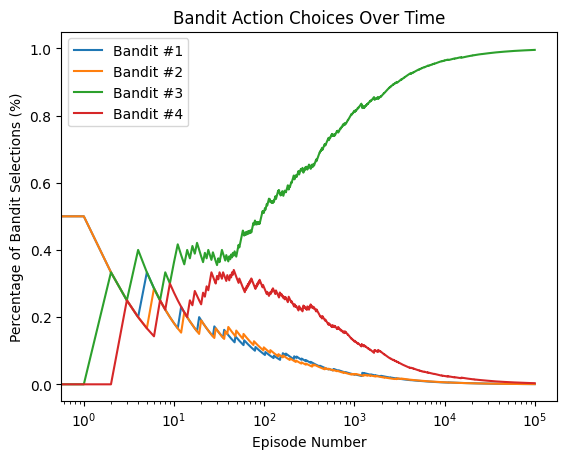

Bandit #1 -> 0.45
Bandit #2 -> 0.35
Bandit #3 -> 0.85
Bandit #4 -> 0.62


In [59]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

посмотрим на динамику выбора ручек
"""

selections_percentage = np.cumsum(history_UCB, axis=0) / np.arange(1, n_iterations + 1).reshape(-1, 1)

import matplotlib.pyplot as plt
for arm in range(n_arms):
    plt.plot(selections_percentage[:, arm], label=f'Bandit #{arm+1}')
plt.xscale('log')
plt.title('Bandit Action Choices Over Time')
plt.xlabel('Episode Number')
plt.ylabel('Percentage of Bandit Selections (%)')
plt.legend()
plt.show()
for i, prob in enumerate(true_bandit_probs, 1):
    print(f"Bandit #{i} -> {prob:.2f}")

# 2.Expert Advice.


###2.1 Теоретическая задача

Sequences of outcomes on which many experts suffer a small loss are
intuitively easier to predict. Show that the **exponentially weighted forecaster** satistifies the following property: for every $n$, for every outcome sequence $y_n$ , and for all $L > 0$,
$$\hat L_n ≤ L + \frac{1}{\mu}\ln\frac{N}{N_L} + \frac{\mu}{8}n$$
where $N_L$ is the cardinality of the set $\{1 \leq i \leq N : L_{i,n} \leq L\}$
### --------------------------------------------------------------------------------------------------------------------------------------------------

Exponentially Weighted Forecaster based on the
potential $\Phi_{\mu}(\mathbf{u})= \frac{1}{\mu} \ln(\sum_{i=1}^N e^{\mu u_i}) $ where $\mu>0$.

$N$ - number of experts.

$n$ - number of times.

$L_{i, n} = \sum_{t=1}^n\ell(f_{i, t}, y_t)$ - cumulative loss of expert $i$

 $\hat L_{n} = \sum_{t=1}^n \ell(\hat p_t, y_t)$ - cumulative loss of forecaster.

**[см ](https://ece.iisc.ac.in/~aditya/Prediction_Learning_and_Games.pdf)Corollary 2.2.**

Let's assume that $\min{L_{i,n}} \geq L$, otherwise $N_L = 0$ and upper bound is infinity.(property holds instantly)

Let's look at variables $W_t = \sum\limits_{i=1}^N w_{i,t} = \sum\limits_{i=1}^Ne^{-\mu L_{i,t}}; W_0 = N$, and ratio $\ln{\frac{W_t}{W_{t-1}}}$:

$$\ln{\frac{W_t}{W_{t-1}}} = \ln{\frac{\sum\limits_{i=1}^Ne^{-\mu L_{i,t}}}{\sum\limits_{j=1}^Ne^{-\mu L_{j,t-1}}}} = \ln{\frac{\sum\limits_{i=1}^N e^{-\mu*l(f_{i,t}, y_t)}e^{-\mu L_{i,t-1}}}{\sum\limits_{j=1}^Ne^{-\mu L_{j,t-1}}}} = \ln{\frac{\sum\limits_{i=1}^N e^{-\mu*l(f_{i,t}, y_t)}w_{i, t-1}}{\sum\limits_{j=1}^Nw_{j, t-1}}}$$

Let's recall property: $\ln{\mathbb{E}(e^{sX})}\leq s*\mathbb{E}(X) + \frac{s^2(b-a)^2}{8}$, where $a \leq X \leq b$. In our case, $l(f_{i,t}, y_t) \in [0, 1]$, so we obtain:

$$\ln{\frac{W_t}{W_{t-1}}} \leq -\mu*\frac{\sum\limits_{i=1}^N l(f_{i,t}, y_t) * w_{i, t-1}}{\sum\limits_{j=1}^Nw_{j, t-1}} + \frac{\mu^2}{8} \leq -\mu l(\frac{\sum\limits_{i=1}^N f_{i,t} * w_{i, t-1}}{\sum\limits_{j=1}^Nw_{j, t-1}}, y_t) + \frac{\mu^2}{8} = -\mu l(\hat{p}_t, y_t) + \frac{\mu^2}{8}$$

Summing up from 1 to n we get $\ln{\frac{W_n}{W_{0}}} \leq -\mu \hat{L}_n + \frac{\mu^2}{8}*n$

But also, we have:

$$\ln{\frac{W_n}{W_0}} = \ln{(\sum\limits_{i=1}^N e^{-\mu L_{i,n}})} - \ln{N} \geq \ln{(\sum\limits_{j=1, L_{j,n} \leq L}^{N_L} e^{-\mu L_{j,n}})} - \ln{N} \geq \ln{(\sum\limits_{j=1, L_{j,n} \leq L}^{N_L} e^{-\mu L})} - \ln{N} = \ln{(N_L * e^{-\mu L})} - \ln{N} = -\mu L - \ln{\frac{N}{N_L}}$$

Combining two limits, we have:

$$-\mu L - \ln{\frac{N}{N_L}} \leq -\mu \hat{L}_n + \frac{\mu^2}{8}*n$$
$$\mu \hat{L}_n \leq \mu L + \ln{\frac{N}{N_L}} + \frac{\mu^2}{8}*n \to \hat{L}_n \leq L + \frac{1}{\mu}\ln{\frac{N}{N_L}} + \frac{n\mu}{8}$$

Statement is proved.

### 2.2 Практическая задача

В этом задании предстоит реализовать exponentially weighted forecaster  по аналогии с polynomially-weighted forecaster второго семинара. И сравнить теоретический и реализованный регреты.

Нужно определить потенциальную функцию и лосс, подсчитать реализованный и теоретический регреты.

**param** выступает в роли параметра метода. Для polynomially-weighted forecaster параметр отвечал за значение степени нормы $p$. Для exponentially weighted forecaster параметр отвечает за $\mu$.

Параметр $\mu$ подберите самостоятельно.

В res функции **step** записываются необходимые результаты для подсчета реализованного регрета


In [35]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

"""
import jax
import jax.numpy as jnp
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import numpy as np

import jax
from functools import partial


@partial(jax.vmap, in_axes=(0, 0, None), out_axes=-1)
def _create_mistakes(key, p, T):
    mistakes = jax.random.bernoulli(key, p=p, shape=(T,))
    return mistakes


def bern_oracle_beta_forecasters(key, n_experts, n_timesteps, a_fcst=2, b_fsct=7, p_oracle=0.5):
    """
    Create a set of forecasters whose probability of being correct is
    distributed according to a Beta(a_fcst, b_fcst) distribution.
    The oracle is a Bernoulli random variable with p=p_oracle.
    """
    key_oracle, key_noise, key_errs = jax.random.split(key, 3)
    keys_noise = jax.random.split(key_noise, n_experts)

    oracle = jax.random.bernoulli(key_oracle, p=p_oracle, shape=(n_timesteps,))
    ps_mistakes = jax.random.beta(key_errs, a=a_fcst, b=b_fsct, shape=(n_experts,))

    mistakes = _create_mistakes(keys_noise, ps_mistakes, n_timesteps)
    experts = (mistakes ^ oracle[:, None]).astype(float)

    return oracle, experts



def forecast_step(experts_curr, regret_prev, param):
    weights = gradp(regret_prev, param)
    forecast = weights @ experts_curr / weights.sum()
    return weights, forecast


def step(regret, xs, param):
    """
    At time t, we make a prediction based on the
    regret (as defined by the potential) obtained at time
    t-1 and the prediction of each forecaster at time t.

    After making a new prediction, we update the regret.
    """
    experts, oracle = xs
    weights, forecast = forecast_step(experts, regret, param)

    loss_forecaster = loss(forecast, oracle)
    loss_experts = loss(experts, oracle)

    iregret_experts = loss_forecaster - loss_experts

    regret_new = regret + iregret_experts

    res = {
        "weights": weights,
        "forecast": forecast,
        "step-loss-experts": loss_experts,
        "step-loss-forecaster": loss_forecaster,
    }


    return regret_new, res

In [36]:
"""

Определим лосс и потенциал для экспотенциального взвешивания

"""

def loss(yhat, y):
    return (yhat - y) ** 2

def potential(x, param):
   x_hat = jnp.exp(x * param)
   return jnp.log(x_hat.sum()) / param

gradp = jax.grad(potential) #функция градиента




In [37]:
"""
генерим ответы природы (oracle) ~ Bernoulli(0.7) и ошибки 10 экспертов (experts) ~  Beta(3,3)
c помощью bern_oracle_beta_forecasters()

подбираем временной горизонт

"""

key = jax.random.PRNGKey(314)

param = np.sqrt(2 * np.log(10) / 500)

n_experts = 10
n_timesteps = 500
a, b =  3, 3 #параметры распределения Beta
p_oracle = 0.7 #параметры распределения  Bernoulli


oracle, experts = bern_oracle_beta_forecasters(key, n_experts, n_timesteps, a, b, p_oracle)

In [38]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

запускаем процесс
"""

regret = jnp.ones(n_experts) #инициализация весов(соответственно регрета) экспертов

xs = (experts, oracle)

part_step = partial(step, param=param)
_, res = jax.lax.scan(part_step, regret, xs) #скользим по xs и получаем res для каждого шага (количество шагов - длина oracle)

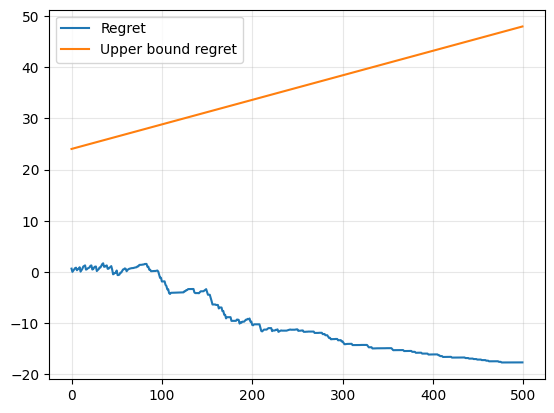

In [39]:
"""
построим  график реализованного и теоретического регретов

необходимые значения можно получить из результатов res
"""
regret_forecaster = res["step-loss-forecaster"].cumsum() - res["step-loss-experts"].cumsum(axis=0).min(axis=1)
timesteps = np.arange(1, n_timesteps + 1)
regret_ubound = np.log(n_experts) / param + timesteps * param / 2

plt.plot(regret_forecaster, label="Regret")
plt.plot(regret_ubound, label="Upper bound regret")
plt.legend()
plt.grid(alpha=0.3)